# Evolving Feedback Controllers with OpenEvolve

Use [OpenEvolve](https://github.com/algorithmicsuperintelligence/openevolve) (an open-source AlphaEvolve implementation) to search for programs that behave like feedback controllers.

The LLM mutates code inside `# EVOLVE-BLOCK-START / END` markers. The evaluator scores each candidate on how well it drives a simulated plant to a setpoint.

## Library layout

All Python code lives in [`src/`](src/):

| Module | Contents |
|---|---|
| [`src/controller.py`](src/controller.py) | `PIDController` class + `simulate()` |
| [`src/plot_pid.py`](src/plot_pid.py) | `plot()` — draws the block diagram |
| [`src/evaluator.py`](src/evaluator.py) | `evaluate(program_path)` — scores a candidate for OpenEvolve |
| [`src/initial_program.py`](src/initial_program.py) | Baseline controller with `EVOLVE-BLOCK` markers |

The **plant** is fixed: `dy/dt = −a·y + b·u` (`a=2`, `b=3`).  
The **interface** is fixed: `Controller(dt)` with `.compute(setpoint, measurement) → float`.  
Only the code inside `EVOLVE-BLOCK` markers is mutated during evolution.

In [1]:
import sys, pathlib

# Make src/ importable from the notebook
ROOT = pathlib.Path().resolve()
sys.path.insert(0, str(ROOT))

from src.controller import PIDController, simulate
from src.plot_pid   import plot as plot_pid
from src.evaluator  import evaluate

# Paths that OpenEvolve will read
INITIAL_PROGRAM = str(ROOT / "src" / "initial_program.py")
EVALUATOR       = str(ROOT / "src" / "evaluator.py")
CONFIG          = str(ROOT / "config.yaml")

print("src/ loaded. Files:")
for p in sorted((ROOT / "src").iterdir()):
    print(" ", p.relative_to(ROOT))

src/ loaded. Files:
  src/__init__.py
  src/__pycache__
  src/controller.py
  src/evaluator.py
  src/initial_program.py
  src/openevolve_output
  src/plot_pid.py


## Sanity-check the baseline

Score the hand-tuned PID before running any evolution, so we know what we're trying to beat.

In [2]:
import os
from pathlib import Path

# Load credentials from .env
env_file = ROOT / ".env"
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ[k.strip()] = v.strip()

# ── Set OPENAI_API_KEY depending on backend ────────────────────────────────
# vLLM: accepts any non-empty string
# Groq:  needs the real GROQ_API_KEY
import yaml
_cfg = yaml.safe_load((ROOT / "config.yaml").read_text())
_api_base = _cfg.get("llm", {}).get("api_base", "")

if "localhost" in _api_base:
    os.environ["OPENAI_API_KEY"] = "local"
    print(f"Backend: local vLLM at {_api_base}")
else:
    os.environ["OPENAI_API_KEY"] = os.environ.get("GROQ_API_KEY", "")
    print(f"Backend: Groq ({_cfg['llm']['primary_model']})")

print("HF_TOKEN loaded:", bool(os.environ.get("HF_TOKEN")))

Backend: local vLLM at http://localhost:8000/v1
HF_TOKEN loaded: True


## Start vLLM server (GPU node only)

Run this cell once after getting a GPU node. It starts the vLLM server in the background and waits until it's ready. Skip if using Groq.

In [3]:
import subprocess, time, urllib.request, os

MODEL = "Qwen/Qwen2.5-Coder-14B-Instruct"
PORT  = 8000
VLLM_URL = f"http://localhost:{PORT}/health"

# Load env vars
env = os.environ.copy()
env_file = ROOT / ".env"
if env_file.exists():
    for line in env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            env[k.strip()] = v.strip()

# Pin to a free GPU
env["CUDA_VISIBLE_DEVICES"] = "0"

# Check GPU
result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                         "--format=csv,noheader"], capture_output=True, text=True, env=env)
print("GPU:", result.stdout.strip() or "not found — run this on a GPU node")

# Kill any existing vLLM server
subprocess.run(["pkill", "-f", "vllm.entrypoints.openai.api_server"],
               capture_output=True)
time.sleep(2)

# Start vLLM server
print(f"Starting vLLM with {MODEL} ...")
log_file = open(ROOT / "vllm.log", "w")
vllm_proc = subprocess.Popen(
    ["python3", "-m", "vllm.entrypoints.openai.api_server",
     "--model", MODEL,
     "--port", str(PORT),
     "--tensor-parallel-size", "1",
     "--dtype", "auto",
     "--max-model-len", "16384"],   # input + output headroom
    env=env,
    stdout=log_file,
    stderr=log_file,
)

for i in range(180):
    time.sleep(2)
    try:
        urllib.request.urlopen(VLLM_URL, timeout=2)
        print(f"vLLM ready after {(i+1)*2}s")
        break
    except Exception:
        if i % 15 == 14:
            print(f"  still loading... ({(i+1)*2}s)")
else:
    print("Timed out waiting for vLLM. Check vllm.log for errors.")

GPU: NVIDIA L40S, 46068 MiB
NVIDIA L40S, 46068 MiB
NVIDIA L40S, 46068 MiB
NVIDIA L40S, 46068 MiB
Starting vLLM with Qwen/Qwen2.5-Coder-14B-Instruct ...
  still loading... (30s)
vLLM ready after 52s


Baseline PID metrics:
{'combined_score': 0.942112,
 'compile_ok': 1.0,
 'ise': 0.126195,
 'overshoot': 0.0,
 'score': 0.942112,
 'ss_error': 0.00047}
Saved pid_diagram.png


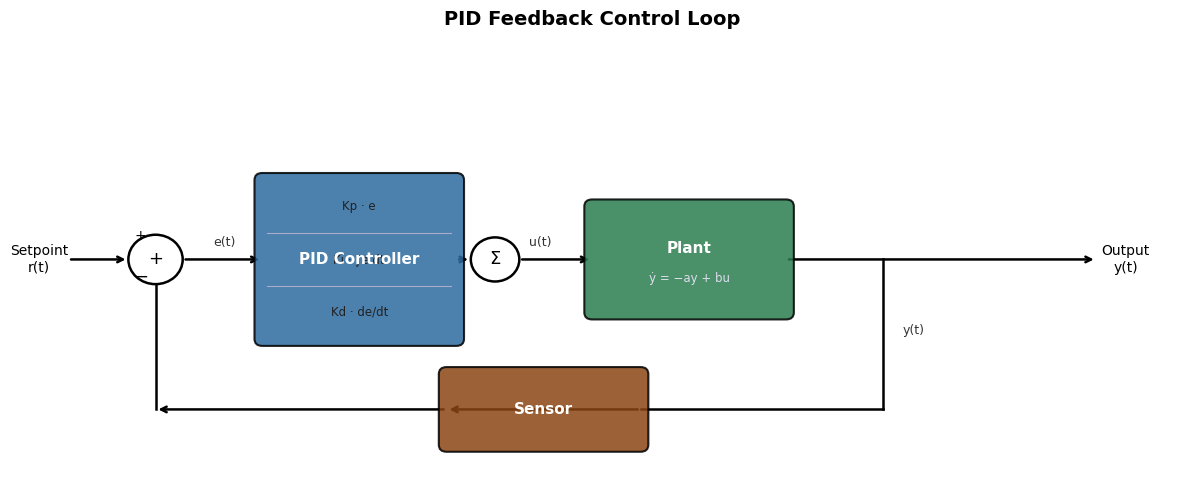

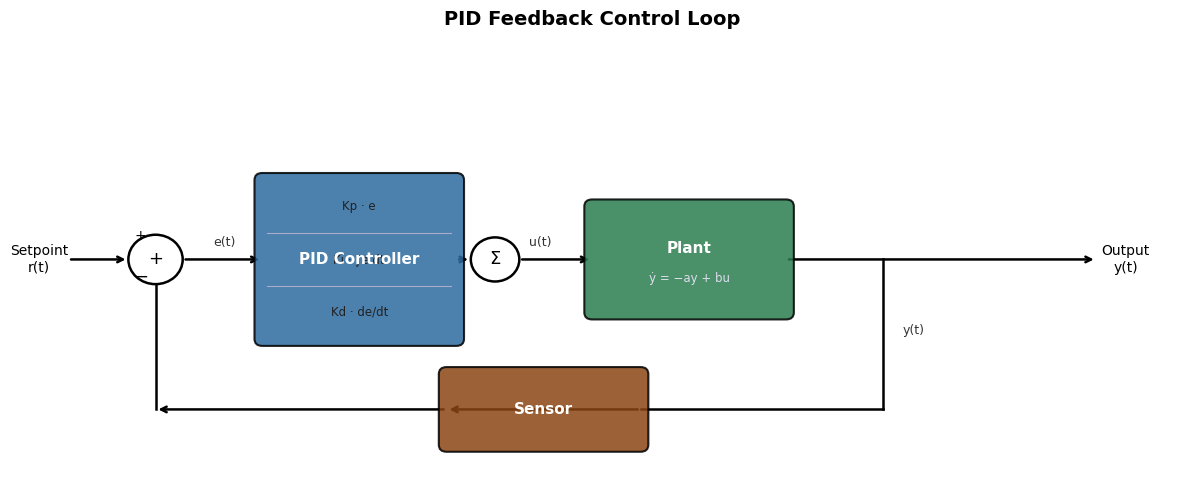

In [4]:
import pprint

# Score the baseline PID — this is the target to beat
baseline_metrics = evaluate(INITIAL_PROGRAM)
print("Baseline PID metrics:")
pprint.pprint(baseline_metrics)

# Also regenerate the block diagram
plot_pid(save_path="pid_diagram.png")

## Run Evolution

Make sure `OPENAI_API_KEY` is set in your environment (or the relevant key for your chosen provider), then run the cell below.

Evolution results are saved to `./openevolve_output/` automatically. The run can be interrupted and resumed.

In [5]:
from openevolve import OpenEvolve
from openevolve.config import Config

config = Config.from_yaml(CONFIG)

evolve = OpenEvolve(
    initial_program_path=INITIAL_PROGRAM,
    evaluation_file=EVALUATOR,
    config=config,
    output_dir=str(ROOT / "openevolve_output"),
)

best = await evolve.run(iterations=100)

print("\n=== Best program metrics ===")
for k, v in best.metrics.items():
    print(f"  {k:<14}: {v}")

2026-03-09 20:48:53,759 - INFO - Logging to /projectnb/rnn-models/bddepasq/Controller-Search/openevolve_output/logs/openevolve_20260309_204853.log
2026-03-09 20:48:53,763 - INFO - Set random seed to 42 for reproducibility
2026-03-09 20:48:53,832 - INFO - Initialized OpenAI LLM with model: Qwen/Qwen2.5-Coder-14B-Instruct
2026-03-09 20:48:53,833 - INFO - Initialized LLM ensemble with models: Qwen/Qwen2.5-Coder-14B-Instruct (weight: 1.00)
2026-03-09 20:48:53,843 - INFO - Initialized prompt sampler
2026-03-09 20:48:53,845 - INFO - Set custom templates: system=evaluator_system_message, user=None
2026-03-09 20:48:53,845 - INFO - Initialized program database with 0 programs
2026-03-09 20:48:53,846 - INFO - Successfully loaded evaluation function from /projectnb/rnn-models/bddepasq/Controller-Search/src/evaluator.py
2026-03-09 20:48:53,846 - WARNING - Configuration has 'cascade_evaluation: true' but evaluator '/projectnb/rnn-models/bddepasq/Controller-Search/src/evaluator.py' does not define '


=== Best program metrics ===
  compile_ok    : 1.0
  score         : 0.96658
  combined_score: 0.96658
  ise           : 0.070899
  overshoot     : 0.0
  ss_error      : 7.9e-05


## Inspect and Plot the Best Controller

In [6]:
print(best.code)

"""
Controller candidate for evolutionary search.

The plant is a first-order system:  dy/dt = -a*y + b*u   (a=2, b=3)
Interface contract (do NOT change):
  - Class name: Controller
  - Constructor signature: __init__(self, dt: float)
  - Method signature:      compute(self, setpoint: float, measurement: float) -> float
  - Actuator saturation is applied externally: u is clipped to [-10, 10]

The single EVOLVE-BLOCK contains both methods so they stay consistent.
"""

class Controller:
    # EVOLVE-BLOCK-START
    def __init__(self, dt: float):
        self.dt = dt
        self.Kp = 3.8  # Further increased Kp for better response
        self.Ki = 2.8  # Further increased Ki for improved stability
        self.Kd = 0.12  # Further increased Kd for smoother control
        self.integral = 0.0
        self.prev_error = 0.0
        self.prev_derivative = 0.0
        self.adaptive_gain = 0.015  # Slightly increased adaptive gain for better adaptation
        self.integral_limit = 96.0  # Sl

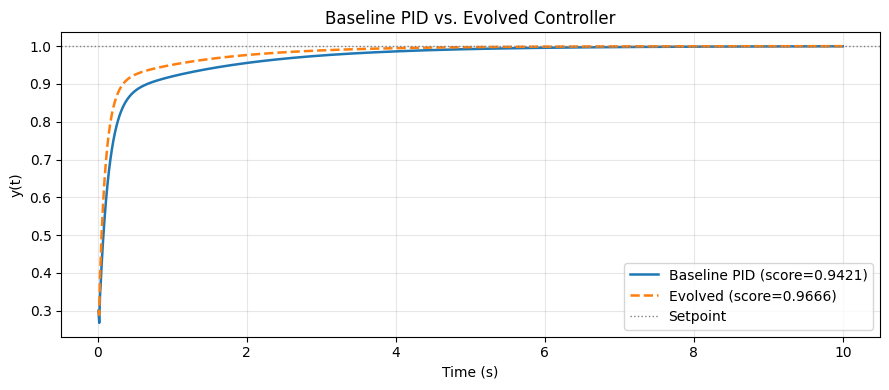

Saved evolved_comparison.png


In [7]:
import importlib, tempfile, os
import matplotlib.pyplot as plt
from src.controller import PIDController

# Load the evolved controller from best.code
with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as f:
    f.write(best.code)
    tmp_path = f.name

spec = importlib.util.spec_from_file_location("best_ctrl", tmp_path)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
BestController = mod.Controller
os.unlink(tmp_path)

# Simulation constants (match evaluator)
DT, A, B = 0.01, 2.0, 3.0
U_MAX, U_MIN = 10.0, -10.0
SETPOINT, DURATION = 1.0, 10.0


def _run(ControllerClass):
    ctrl = ControllerClass(DT)
    y, t, ts, ys = 0.0, 0.0, [], []
    for _ in range(int(DURATION / DT)):
        u = ctrl.compute(SETPOINT, y)
        u = max(U_MIN, min(U_MAX, u))
        y += (-A * y + B * u) * DT
        t += DT
        ts.append(t); ys.append(y)
    return ts, ys


class _BaselineWrapper:
    def __init__(self, dt):
        self._pid = PIDController(Kp=3.0, Ki=2.0, Kd=0.1, dt=dt)
    def compute(self, sp, m):
        return self._pid.compute(sp, m)


t_base, y_base = _run(_BaselineWrapper)

try:
    t_best, y_best = _run(BestController)
    best_label = f"Evolved (score={best.metrics['score']:.4f})"
    plot_best = True
except Exception as e:
    print(f"Warning: evolved controller failed during simulation: {e}")
    print("Plotting baseline only.")
    plot_best = False

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_base, y_base, lw=1.8, label=f"Baseline PID (score={baseline_metrics['score']:.4f})")
if plot_best:
    ax.plot(t_best, y_best, lw=1.8, ls="--", label=best_label)
ax.axhline(SETPOINT, color="gray", ls=":", lw=1, label="Setpoint")
ax.set_xlabel("Time (s)"); ax.set_ylabel("y(t)")
ax.set_title("Baseline PID vs. Evolved Controller")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evolved_comparison.png", dpi=150)
plt.show()
print("Saved evolved_comparison.png")